# **Health** **Insurance** **Price** **Prediction**


# Problem Statement

The goal of this project is to develop a predictive model that accurately estimates the medical insurance costs for individuals based on various demographic, lifestyle, and health-related factors. By applying machine learning techniques, we aim to assist insurance companies in better understanding their risk profiles and help individuals gain insights into how different factors influence their insurance premiums.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data=pd.read_csv("insurance.csv")

In [ ]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# Understand the Variables


**Domain Analysis**
The descriptions of the variables based on the insurance dataset:

1. **Age**
   - **Description:** Age of the primary beneficiary covered by health insurance.
   - **Type:** Continuous numerical variable.

2. **Sex**
   - **Description:** Gender of the insurance contractor.
   - **Type:** Categorical variable with two levels: female, male.

3. **BMI (Body Mass Index)**
   - **Description:** Body mass index, which is a measure of body fat based on height and weight.
   - **Type:** Continuous numerical variable.
   - **Ideal Range:** Ideally between 18.5 to 24.9 kg/m².

4. **Children**
   - **Description:** Number of children covered by health insurance or number of dependents.
   - **Type:** Discrete numerical variable.

5. **Smoker**
   - **Description:** Binary indicator if the beneficiary is a smoker.
   - **Type:** Categorical variable with two levels: yes, no.

6. **Region**
   - **Description:** The beneficiary's residential area in the US.
   - **Type:** Categorical variable with four levels: northeast, southeast, southwest, northwest.

7. **Charges**
   - **Description:** Individual medical costs billed by health insurance.
   - **Type:** Continuous numerical variable.

# Basic checks

In [ ]:
#find number of rows and columns
data.shape

(1338, 7)

In [ ]:
#print first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#print last 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
#check info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
#check datatype of each column
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
#print all columns
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
#print numerical columns
num_data=data.select_dtypes(include=['int64','float64'])
num_data

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [ ]:
#print categorical columns
cat_data=data.select_dtypes(include=['object'])
cat_data

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [ ]:
#get the statistical report for numerical data
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
#get the statistical report for categorical data
data.describe(include=['object'])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [ ]:
#check unique values
for x in cat_data:
  print(x,'-->',data[x].unique())


sex --> ['female' 'male']
smoker --> ['yes' 'no']
region --> ['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
#check value counts
for x in cat_data:
  print(data[x].value_counts())
  print()


sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



# Data Cleaning

In [ ]:
#check missing values
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#check for duplicates
data.duplicated().sum()

np.int64(1)

In [ ]:
#drop duplicate
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

# Exploratory data analysis

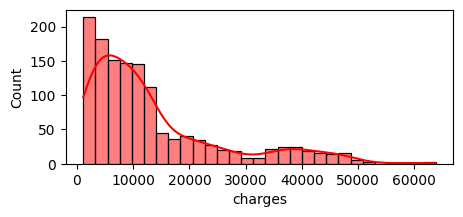

In [ ]:
#check the distribution of charges

plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True,color='red')
plt.show()

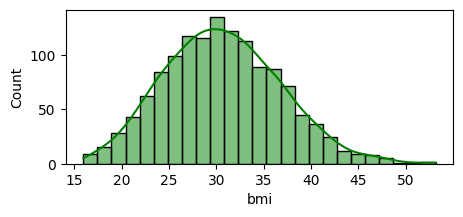

In [ ]:
#check the distribution of BMI

plt.figure(figsize=(5,2))
sns.histplot(data,x='bmi',kde=True,color='green')
plt.show()

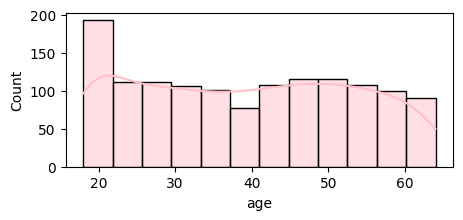

In [ ]:
#check the distribution of Age

plt.figure(figsize=(5,2))
sns.histplot(data,x='age',kde=True,color='pink')
plt.show()

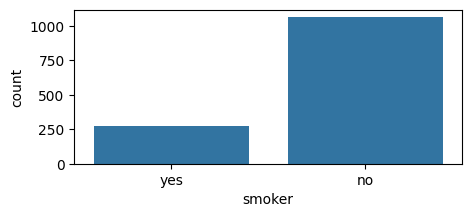

In [ ]:
#check how many customers are smokers and non-smokers

plt.figure(figsize=(5,2))
sns.countplot(data,x='smoker')
plt.show()

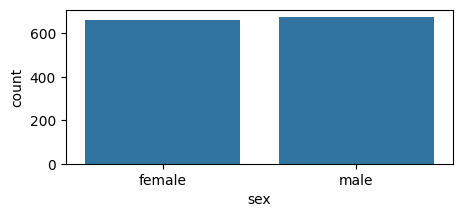

In [ ]:
#check how many customers are male and female

plt.figure(figsize=(5,2))
sns.countplot(data,x='sex')
plt.show()

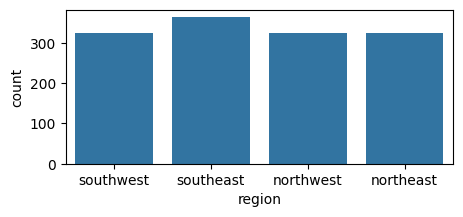

In [ ]:
#check how mnay customers are from different region

plt.figure(figsize=(5,2))
sns.countplot(data,x='region')
plt.show()

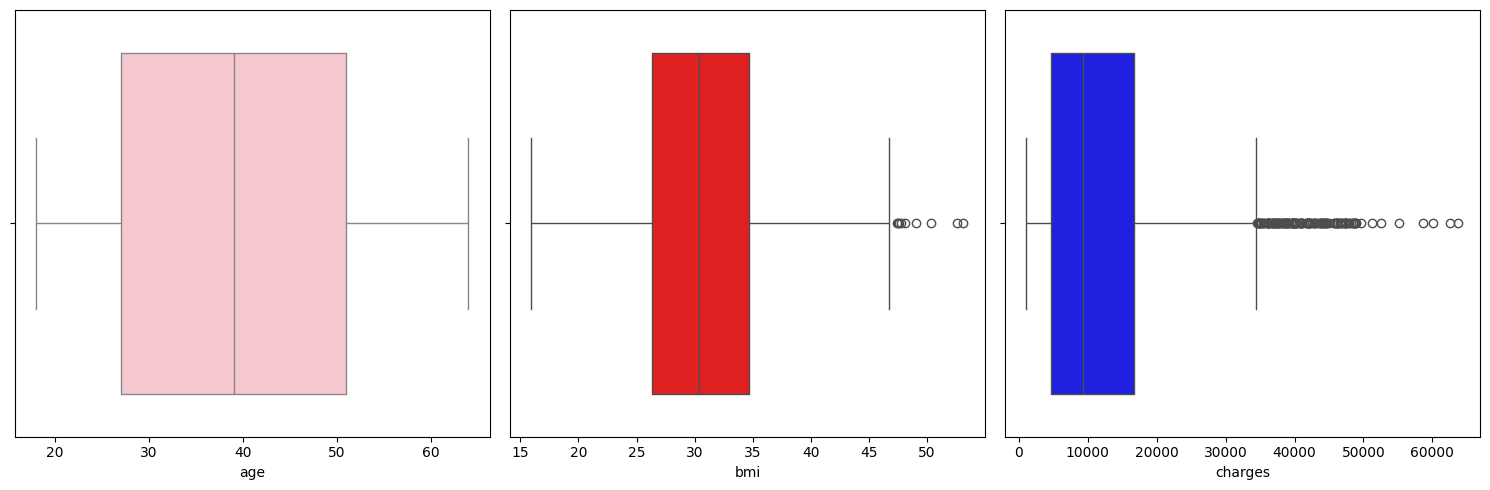

In [ ]:
#check are there any outliers in age,bmi and charges

fig, ax = plt.subplots(1,3,figsize=(15,5))
sns.boxplot(data , x='age',ax=ax[0],color='pink')
sns.boxplot(data, x='bmi',ax=ax[1],color='red')
sns.boxplot(data, x='charges',ax=ax[2],color='blue')
plt.tight_layout()
plt.show()

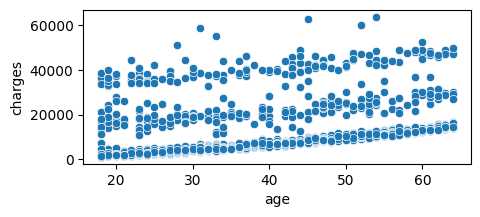

In [ ]:
#find relationship between age and charges

plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='charges')
plt.show()

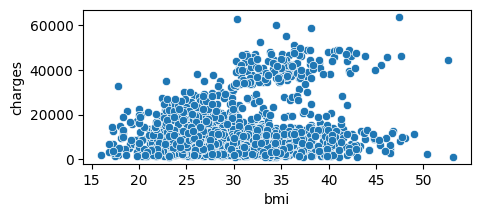

In [ ]:
#find relationship between bmi and charges

plt.figure(figsize=(5,2))
sns.scatterplot(data,x='bmi',y='charges')
plt.show()

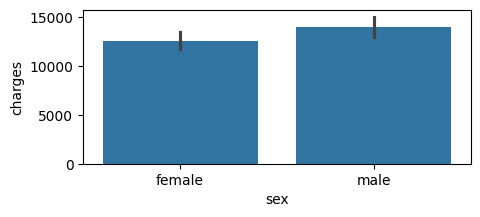

In [ ]:
#check how charges vary with gender

plt.figure(figsize=(5,2))
sns.barplot(data,x='sex',y='charges')
plt.show()

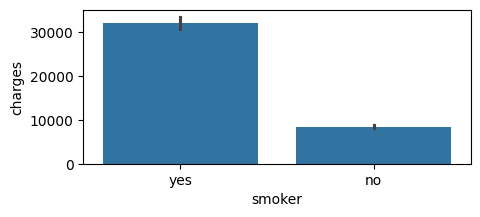

In [ ]:
#check how charges vary with smokers or non-smokers

plt.figure(figsize=(5,2))
sns.barplot(data,x='smoker',y='charges')
plt.show()

# Pairplot

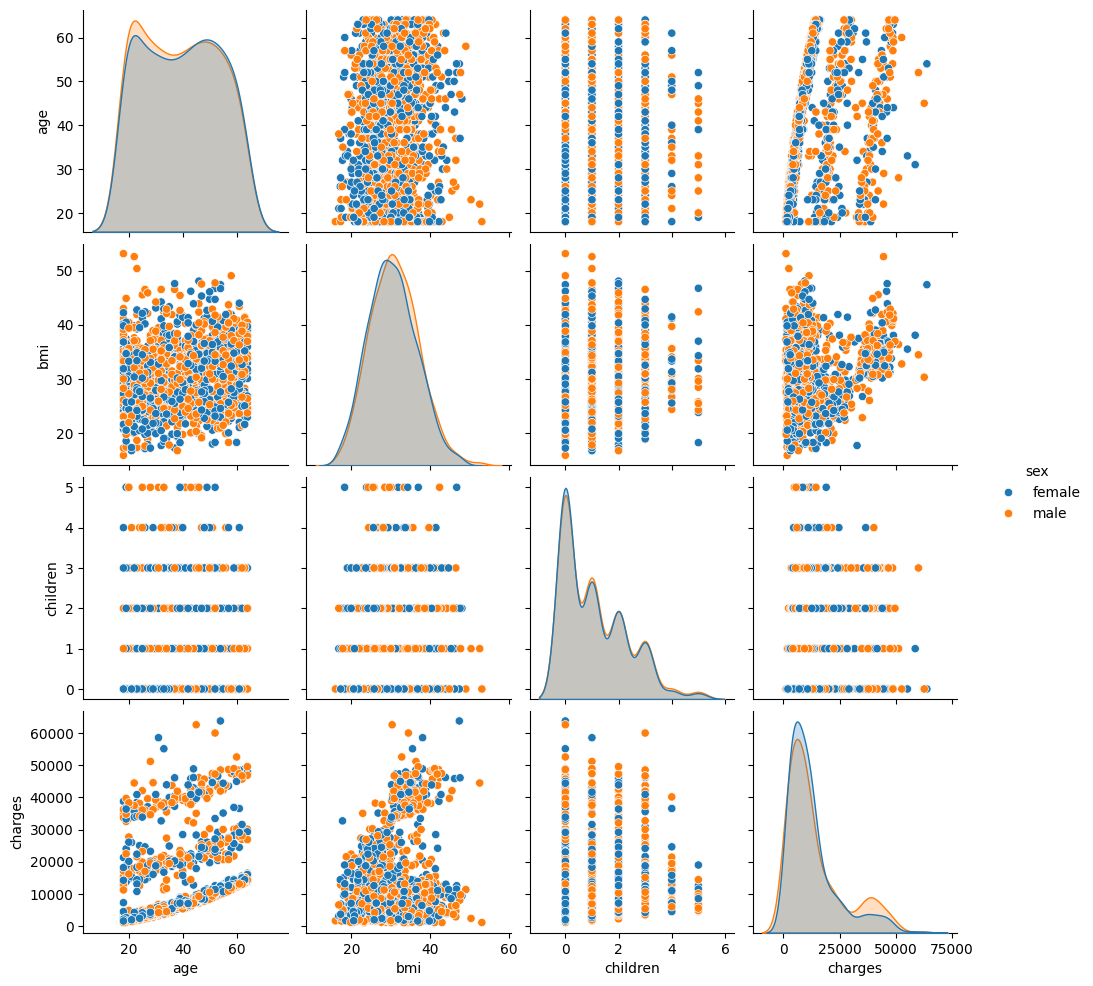

In [ ]:
sns.pairplot(data,hue='sex')

# Heatmap

<Axes: >

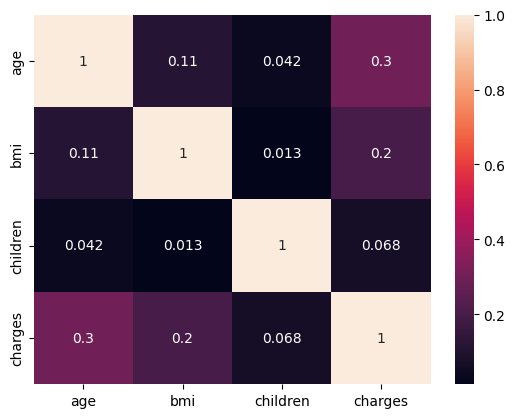

In [ ]:
sns.heatmap(num_data.corr(),annot=True)

Handling Outliers
-outliers are extreme values which are different from actual data



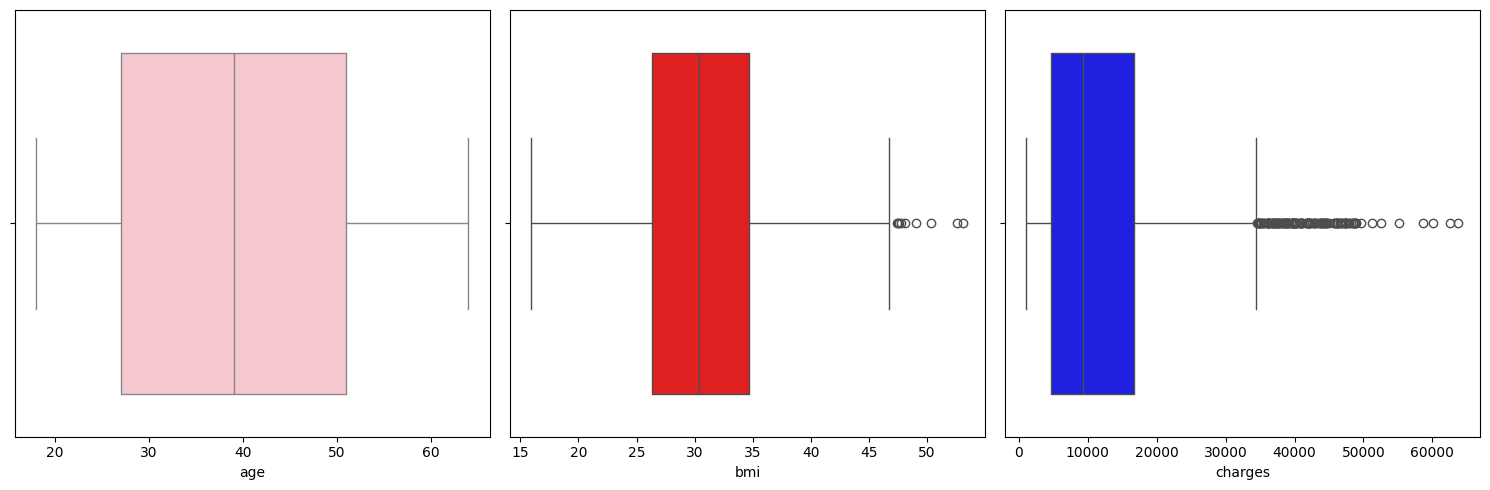

In [ ]:
#check the direction of outliers in numerical column

fig,ax=plt.subplots(1,3,figsize=(15,5))
sns.boxplot(data,x='age',ax=ax[0],color='pink')
sns.boxplot(data,x='bmi',ax=ax[1],color='red')
sns.boxplot(data,x='charges',ax=ax[2],color='blue')
plt.tight_layout()
plt.show()


outliers are seen in bmi and charges

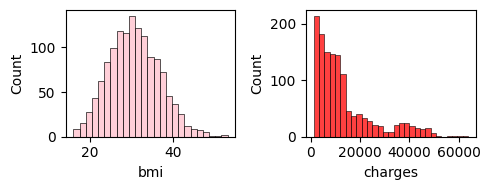

In [ ]:
#check the distribution of bmi and charges

fig,ax=plt.subplots(1,2,figsize=(5,2))
sns.histplot(data,x='bmi',ax=ax[0],color='pink')
sns.histplot(data,x='charges',ax=ax[1],color='red')
plt.tight_layout()


distribution of bmi is normal.
distribution of charges is right skewed.

In [ ]:
data['bmi'].skew()

np.float64(0.28391419385321137)

In [ ]:
data['charges'].skew()

np.float64(1.5153909108403483)

# Ways to find outlier values

1.IQR:used when data distribution is skewed.

2.3-Sigma rule:used when data is normal.

3.outliers should be removed or replaced only if %less than 5%

## **IQR**
Charges distribution is skewed hence we go with IQR method to find outliers.
1. Find Q1
2. Find Q3
3. IQR = Q3-Q1
4. lower_limit = Q1-1.5*IQR
5. upper_limit = Q3+1.5*IQR
6. If any value in charges is less than lower limit and greater than upper limit then its an outlier.


In [ ]:
import pandas as pd

data = pd.read_csv('insurance.csv')   # or your correct file name

In [ ]:
# find outliers in charges
Q1 = data.loc[:,'charges'].quantile(0.25)
Q3 = data.loc[:,'charges'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5* IQR


In [ ]:
# filter values less than lower limit
data[data.loc[:,'charges']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
# filter values greater than upper limit
data[data.loc[:,'charges']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [ ]:
# Over all
data[(data.loc[:,'charges']<lower_limit)|(data.loc[:,'charges']>upper_limit)]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [ ]:
# find %
len(data[(data.loc[:,'charges']<lower_limit)|(data.loc[:,'charges']>upper_limit)])/len(data)*100

10.388639760837071

Since % of outliers are more than 5% i.e 10% they are not outliers they are adding some meaning to the data.

## **3 sigma rule**
The distribution of bmi is normal hence we find outliers using 3 sigma rule.

1. find mean
2. find standard deviation
3. lower_limit = mean - 3* std
4. upper_limit = mean + 3*std
5. If any value less than lower_limit or greater than upper limit is considered as outlier.

In [ ]:
mean_val = data.loc[:,'bmi'].mean()
std_val = data.loc[:,'bmi'].std()
lower_limit = mean_val - 3* std_val
upper_limit = mean_val  + 3* std_val

In [ ]:
# filter all the values less than lower
data[data.loc[:,'bmi']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
# filter values greater than upper
# filter all the values less than lower
data[data.loc[:,'bmi']> upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [ ]:
# filter values that are less than lower or greater than upper
data[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']> upper_limit)]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [ ]:
# find percentage
len(data[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']> upper_limit)])/len(data)*100

0.29895366218236175

Since % of outliers are ver less 0.2% lets fill with mean.

In [ ]:
# fill with mean
data.loc[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']>
                                            upper_limit),'bmi']=data.loc[:,'bmi'].mean()

In [ ]:
len(data[(data.loc[:,'bmi']<lower_limit) | (data.loc[:,'bmi']> upper_limit)])/len(data)*100

0.0

## **Encoding**
Process of converting text into numbers.
* Label Encoder
* One hot Encoder
* Ordinal Encoder
* Manual Encoder

**Smoker**


In [ ]:
# Label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'smoker']=le.fit_transform(data.loc[:,'smoker'])


**Sex**

In [ ]:
# one hot encoder
data =pd.get_dummies(data,columns=['sex'],dtype='int')
data

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,1,southwest,16884.92400,1,0
1,18,33.770,1,0,southeast,1725.55230,0,1
2,28,33.000,3,0,southeast,4449.46200,0,1
3,33,22.705,0,0,northwest,21984.47061,0,1
4,32,28.880,0,0,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,northwest,10600.54830,0,1
1334,18,31.920,0,0,northeast,2205.98080,1,0
1335,18,36.850,0,0,southeast,1629.83350,1,0
1336,21,25.800,0,0,southwest,2007.94500,1,0


**region**

In [ ]:
data.loc[:,'region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

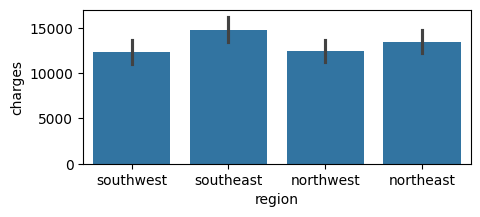

In [ ]:
# target encoding
# relationship between region and charges
plt.figure(figsize=(5,2))
sns.barplot(data , x='region',y='charges')
plt.show()

In [ ]:
# southeast: 3 , northeast:2 , northwest : 1 , southwest=0
data.loc[:,'region']=data.loc[:,'region'].map({'southeast':3,'northeast':2,'northwest':1,'southwest':0})


In [ ]:
data

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,1,0,16884.92400,1,0
1,18,33.770,1,0,3,1725.55230,0,1
2,28,33.000,3,0,3,4449.46200,0,1
3,33,22.705,0,0,1,21984.47061,0,1
4,32,28.880,0,0,1,3866.85520,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,1,10600.54830,0,1
1334,18,31.920,0,0,2,2205.98080,1,0
1335,18,36.850,0,0,3,1629.83350,1,0
1336,21,25.800,0,0,0,2007.94500,1,0


## **Scaling**
Scaling brings all the numerical column values into a same scale so that calculations become easy for ML algorithms

- Min max scaler : It brings everything to a range of 0 to 1
- Standard scaler : It make mean =0 , std = 1 for the column

**MinMax Scaler**

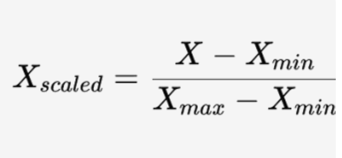

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("insurance.csv")

In [ ]:
df1 = data.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df1[['age']]=scaler.fit_transform(df1[['age']])
df1[['bmi']]=scaler.fit_transform(df1[['bmi']])

**Standard Scaler**

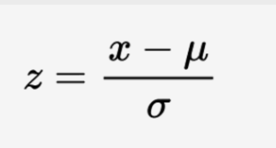

In [ ]:
df2 = data.copy()


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df2[['age']]=scaler.fit_transform(df2[['age']])
df2[['bmi']]=scaler.fit_transform(df2[['bmi']])

In [ ]:
# age , bmi
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **Transformation**

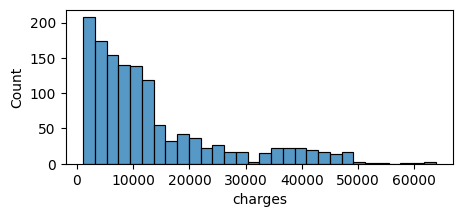

In [ ]:
# Linear Regression expect target to be a normal
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges')
plt.show()


In [ ]:
# convreting skewed to normal is possible with log
df2[['charges']]=np.log(df2[['charges']])

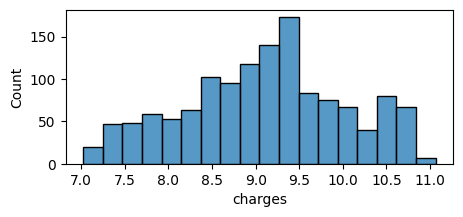

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(df2,x='charges')
plt.show()

# **Feature** **engineering**


- Selecting best features
- removing features which are not important
- creating new features

In [ ]:
df = data[['age','bmi','charges','children']]


<Axes: >

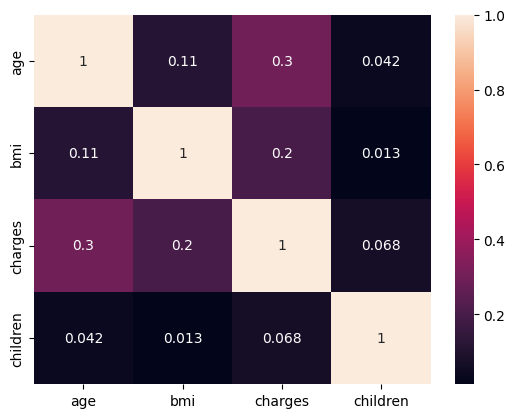

In [ ]:
sns.heatmap(df.corr(),annot=True)

- Include columns which has high correlation with target and drop the column which has less correlation.
- Check correlation among input features.
- If any two features representing high correlation we can drop one of them.

**Split** **Data** **for** **X** **and** **Y**

In [ ]:
x= df2.drop(columns='charges')
y = df2.loc[:,'charges']

# **split** **data** **for** **training** **and** **testing**

In [ ]:
# 70:30 or 80:20
# xtrain , xtest
# ytrain , ytest
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
data.shape

(1338, 7)

In [ ]:
x_train.shape

(1070, 6)

In [ ]:
x_test.shape

(268, 6)

In [ ]:
y_train.shape


(1070,)

In [ ]:
y_test.shape

(268,)

# **Model** **building**

In [ ]:
x = data.drop('charges', axis=1)
y = data['charges']

In [ ]:
x = pd.get_dummies(x, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Make predictions/Testing : x_test
y_pred=model.predict(x_test)

In [ ]:
# slope
model.coef_

array([ 2.56975706e+02,  3.37092552e+02,  4.25278784e+02, -1.85916916e+01,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [ ]:
# intercept
model.intercept_

np.float64(-11931.21905032666)

## **Evaluate the Model**
* MSE
* MAE
* RMSE
* MAPE
* r2 score
* adjusted r2 score

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

In [ ]:
# y_test,y_pred
# mean square error
mse=mean_squared_error(y_test,y_pred)
mse

33596915.85136145

In [ ]:
# mean absolute error
mae = mean_absolute_error(y_test,y_pred)
mae

4181.19447375365

In [ ]:
# root mean squared error
rmse = np.sqrt(mse)
rmse

np.float64(5796.284659276273)

In [ ]:
# mean absolute percentage error
mape = mean_absolute_percentage_error(y_test,y_pred)
mape

0.46888255979146803

In [ ]:
# r2 score
r2=r2_score(y_test,y_pred)
r2

0.7835929767120724

82% better model.

In [ ]:
# adjusted r2 score
# adj = 1-(1-r2)(n-1)/(n-p-1)
n = x_test.shape[0]
n # number of samples in test data

268

In [ ]:
p = x_test.shape[1]
p # number of input columns

8

In [ ]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.7769085898923681

# **KNN Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
# mse
mean_squared_error(y_test,y_pred)

120279949.47236343

In [ ]:
#mae
mean_absolute_error(y_test,y_pred)

6818.6056120932835

In [ ]:
# rmse
np.sqrt(mse)

np.float64(5796.284659276273)

In [ ]:
#mape
mean_absolute_percentage_error(y_test,y_pred)

0.7054372872155211

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.22524359254595927

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.20131289270181896

# Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

112058193.17176215

In [ ]:
# mean absolute error
mean_absolute_error(y_test,y_pred)

7779.40359979849

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(10585.754256157761)

In [ ]:
# mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred)

1.3806762904015848

In [ ]:
# r2 score
r2 = r2_score(y_test,y_pred)
r2

0.27820219788591294

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.25590728507930016

# K fold

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=kfold)

In [ ]:
scores

array([0.71282654, 0.5853862 , 0.81113667, 0.79908009, 0.64309313])

In [ ]:
print(np.mean(scores))

0.7103045251533701


# Stratified K Fold


In [ ]:
from sklearn.model_selection import StratifiedKFold
model = DecisionTreeRegressor(criterion='squared_error',max_depth=6,max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train)

In [ ]:
scores

array([0.75261126, 0.88469693, 0.68585809, 0.56345028, 0.38263291])

In [ ]:
print(np.mean(scores))

0.6538498937445653


# Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=10,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
'''
n_estimators=10,max_depth=6,max_features=5,
bootstrap=True,min_samples_split=5,min_samples_leaf=3'''

'\nn_estimators=10,max_depth=6,max_features=5,\nbootstrap=True,min_samples_split=5,min_samples_leaf=3'

In [ ]:
mean_squared_error(y_test,y_pred)

18797981.070335403

In [ ]:
mean_absolute_error(y_test,y_pred)

2468.734256248803

In [ ]:
np.mean(mean_squared_error(y_test,y_pred))

np.float64(18797981.070335403)

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

0.3083243372324951

In [ ]:
r2 = r2_score(y_test,y_pred)
r2

0.8789170069880314

In [ ]:
# adjusted r2 score
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8751769917598625

# Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

18740277.703438837

In [ ]:
mean_absolute_error(y_test,y_pred)

2442.282804856014

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(4329.00423924935)

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

0.2995948842776338

In [ ]:
r2 = r2_score(y_test,y_pred)
r2

0.8792886903270326

In [ ]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8755601556653193

# XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

23434704.61742758

In [ ]:
mean_absolute_error(y_test,y_pred)

2765.7468132880863

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(4840.9404682796485)

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

0.34992891223847394

In [ ]:
r2=r2_score(y_test,y_pred)
r2

0.8490505887407566

In [ ]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.844388058663251

**Grid Search CV with gradient boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
model = GradientBoostingRegressor()
parameters = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.1,0.2]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5 )
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [5, 6, 7],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}


In [ ]:
model = GradientBoostingRegressor(learning_rate=0.01,max_depth=5,n_estimators=300)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [ ]:
mean_squared_error(y_test,y_pred)

20364749.859995313

In [ ]:
r2_score(y_test,y_pred)

0.868825016060924

**Randomised Search for Gradient Boosting**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
parameters = {'max_depth':[5,6,7],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.1,0.2]}
model = GradientBoostingRegressor()
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5 , n_iter=10)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(),
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [5, 6, 7],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}


In [ ]:
model = GradientBoostingRegressor(n_estimators=300,max_depth=5,learning_rate=0.01)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

20384761.314321063

In [ ]:
r2_score(y_test,y_pred)

0.868696116751194

**XGBOOST Grid Search CV**

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor()
parameters = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
              'learning_rate':[0.1,0.01,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
              'reg_lambda':[1,5,8,10]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.01, 0.2],
                         'max_depth': [4, 5, 6],
                         'n_estimators': [10, 50, 100, 200, 300],
                         'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                         'reg_lambda': [1, 5, 8, 10]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50, 'reg_alpha': 0.3, 'reg_lambda': 8}


In [ ]:
model = XGBRegressor(learning_rate= 0.1,max_depth= 4,n_estimators=50,
                   reg_alpha=0.1,reg_lambda=10 )
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

18565130.135144502

In [ ]:
r2_score(y_test,y_pred)

0.8804168642361613

**RandomizedSearch CV with XGBOOST**

In [ ]:

model = XGBRegressor()
parameters = {'max_depth':[4,5,6],'n_estimators':[10,50,100,200,300],
              'learning_rate':[0.1,0.01,0.2],'reg_alpha':[0.1,0.01,0.2,0.3],
              'reg_lambda':[1,5,8,10]}
random=RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=30)
random.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=30,
                   param_distributions={'learning_rate': [0.1, 0.01, 0.2],
                                        'max_depth': [4, 5, 6],
                                        'n_estimators': [10, 50, 100, 200, 300],
                                        'reg_alpha': [0.1, 0.01, 0.2, 0.3],
                                        'reg_lambda': [1, 5, 8, 10]})

In [ ]:
print(random.best_params_)

{'reg_lambda': 5, 'reg_alpha': 0.3, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01}


In [ ]:
model = XGBRegressor(reg_lambda=10,reg_alpha= 0.1,n_estimators= 50,
                     max_depth= 6,learning_rate=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

17960683.08714739

In [ ]:
r2_score(y_test,y_pred)

0.8843102747792879

# Support vector Regressor

In [ ]:
from sklearn.svm import SVR
model = SVR()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

166492259.9106511

In [ ]:
r2_score(y_test,y_pred)

-0.07242267496062205

# Grid Search CV

In [ ]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
model = SVR()
parameters ={'kernel':['linear','poly','rbf','sigmoid'],'C':[1,5,10,15],'gamma':[0.1,0.01,0.001]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5,scoring='r2')
grid.fit(x_train,y_train)

In [ ]:
print(grid.best_params_)

In [ ]:
model = SVR(C=10,gamma=0.1,kernel='rbf')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [ ]:
mean_squared_error(y_test,y_pred)

In [ ]:
r2_score(y_test,y_pred)

# randomized Search CV

In [ ]:
model = SVR()
parameters ={'kernel':['linear','poly','rbf','sigmoid'],'C':[1,5,10,15],'gamma':[0.1,0.01,0.001]}
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=10,scoring='r2')
random.fit(x_train,y_train)



In [ ]:
print(random.best_params_)

In [ ]:
model = SVR(kernel='rbf',C=10,gamma=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)


In [ ]:
r2_score(y_test,y_pred)